# 10-Distributed Training at Scale (Ray Train)

Lesson 05's DDP synchronized gradients across a *fixed*, single-flat set of workers using ring all-reduce, and Lesson 09 orchestrated a multi-step *pipeline* of jobs, but neither addressed what happens when "a job" itself must span dozens of nodes with real network hierarchy -- a fast NVLink fabric within a node, a much slower Ethernet or InfiniBand fabric between nodes. Treating a 64-GPU, 8-node cluster as one flat 64-way ring, exactly as Lesson 05's DDP would by default, ignores that topology entirely and routes gradient traffic across the slow inter-node links far more than necessary.

**Ray Train** operates one layer above DDP: it manages the *cluster-wide* actor placement, elastic worker scaling, and can orchestrate **hierarchical all-reduce** -- reducing within each node's fast local group first, then only once across nodes -- exactly the kind of topology-aware communication strategy Lesson 08's scheduler made physically possible by keeping GPU sets NVLink-local in the first place.

We will implement and numerically compare flat ring all-reduce against hierarchical (two-tier) all-reduce cost models, quantify the straggler effect that emerges as worker count grows, and use a real `torch.distributed` process group to demonstrate the actor-group communication pattern -- the tool for this lesson is **Ray Train**.

## 1. The Physics of Cluster-Scale Hierarchical Communication

### Flat Ring All-Reduce at Cluster Scale

Recall from Lesson 05 that a flat ring all-reduce over $W$ workers moves, per worker:

$$\text{Data}_{\text{flat}} = 2 \cdot \frac{W-1}{W} \cdot N$$

This formula is topology-blind: it assumes every worker-to-worker link has identical bandwidth $BW$. At cluster scale that assumption breaks -- intra-node NVLink bandwidth $BW_{\text{intra}}$ is commonly $10$-$20\times$ inter-node network bandwidth $BW_{\text{inter}}$, so a flat ring spends most of its *time* budget on the few ring edges that happen to cross a node boundary.

### Hierarchical (Two-Tier) All-Reduce

Let $W$ workers be organized into $G$ groups (nodes) of $g = W/G$ workers each. Hierarchical all-reduce runs in three phases:

1. **Intra-node reduce-scatter/all-reduce** within each group of size $g$, over the fast fabric.
2. **Inter-node all-reduce** across just the $G$ group-representative values, over the slow fabric.
3. **Intra-node broadcast** of the final result back to every worker in the group.

The time cost, using the same ring-cost shape as Lesson 05 but with two distinct bandwidths, is:

$$T_{\text{hier}} = \underbrace{2\cdot\frac{g-1}{g}\cdot\frac{N}{BW_{\text{intra}}}}_{\text{intra-node phase (fast)}} \;+\; \underbrace{2\cdot\frac{G-1}{G}\cdot\frac{N}{BW_{\text{inter}}}}_{\text{inter-node phase (slow)}}$$

compared against the flat ring's single-tier time:

$$T_{\text{flat}} = 2\cdot\frac{W-1}{W}\cdot\frac{N}{BW_{\text{inter}}}$$

(a topology-blind ring pays $BW_{\text{inter}}$ for essentially all of its traffic, since it does not privilege node-local neighbors in the ring ordering). Both terms share the same $\frac{k-1}{k}$ ring-saturation shape proven in Lesson 05 to converge quickly to a constant near $1$ regardless of $k$ -- which has a sharp consequence here: $T_{\text{flat}}$'s dependence on $W$ saturates almost immediately (by $W{=}8$, $\frac{7}{8}=0.875$ is already most of the way to the asymptote), so hierarchical's advantage is **not** an ever-widening gap. It is largest when the flat ring is still far from saturated (small clusters), and it *shrinks* as $G$ grows, because $T_{\text{hier}}$'s inter-node term saturates toward that same asymptotic ceiling while still paying its intra-node term $2\frac{g-1}{g}\frac{N}{BW_{\text{intra}}}$ as a fixed tax on every step. Past some crossover node count, that fixed tax can exceed the shrinking marginal savings, and hierarchical stops being the cheaper option in this simplified cost model.

### Elastic Scaling and Communication Overhead Fraction

Let $T_{compute}$ be per-step compute time (assumed roughly constant per worker) and $T_{comm}(W)$ the communication time at worker count $W$. Effective throughput speedup over a single worker is bounded by:

$$\text{Speedup}(W) = \frac{W \cdot T_{compute}}{T_{compute} + T_{comm}(W)}$$

which is Amdahl's-law-shaped: as $W$ grows, $T_{comm}(W)$ (via the flat-ring or hierarchical formula above) eventually dominates, and speedup saturates well below the ideal linear line $\text{Speedup}(W) = W$.

### The Straggler Effect as an Order-Statistic

Every synchronous step must wait for the *slowest* of $W$ workers. If each worker's step time is an i.i.d. random variable $X_i$ (drawn from some latency distribution with mean $\mu$ and modeled here as exponential with rate $1/\mu$ for tractability), the expected time for the step is the expectation of the **maximum** of $W$ draws:

$$\mathbb{E}[\max(X_1, \dots, X_W)] = \mu \cdot H_W = \mu \sum_{k=1}^{W} \frac{1}{k} \approx \mu \cdot (\ln W + \gamma)$$

where $H_W$ is the $W$-th harmonic number and $\gamma \approx 0.5772$ is the Euler-Mascheroni constant. Step time therefore grows *logarithmically* with worker count purely from straggler effects, even if every individual worker's hardware is identical and $T_{comm}$ is ignored entirely -- variance across workers is its own scaling tax.

## 2. Imperative Execution: A Real Sub-Grouped Process Group and Communication Cost Sweep

We initialize a real `torch.distributed` process group and construct actual `ProcessGroup` subgroups mirroring Ray Train's node-local actor grouping (the same primitive a real multi-node hierarchical all-reduce implementation would use), then compute the flat-vs-hierarchical communication cost sweep from Section 1 for a representative model size.

In [1]:
# Required installations: pip install torch ray (ray requires a real multi-node Ray cluster to launch actors)

import torch
import torch.distributed as dist

print("--- 🚀 Initializing Ray Train Cluster-Scale Communication Sandbox ---")

WORLD_SIZE = 1
subgroup_created = False

try:
    import os
    os.environ.setdefault("MASTER_ADDR", "127.0.0.1")
    os.environ.setdefault("MASTER_PORT", "29504")
    dist.init_process_group(backend="gloo", rank=0, world_size=WORLD_SIZE)
    print(f"   ✅ Real torch.distributed process group initialized: world_size={dist.get_world_size()}")

    # A real ProcessGroup subgroup call -- the exact primitive hierarchical all-reduce builds on
    # (in a genuine multi-node run this would be one subgroup per physical node)
    node_local_group = dist.new_group(ranks=[0])
    subgroup_created = True
    tensor = torch.ones(4)
    dist.all_reduce(tensor, group=node_local_group)
    print(f"   ✅ Real node-local subgroup all-reduce executed: result={tensor.tolist()} (rank count in group=1)")

    dist.destroy_process_group()

except Exception as e:
    print(f"   [SYSTEM NOTE]: Falling back to simulated multi-node actor telemetry ({type(e).__name__}: {e})")
    print("   [SIMULATED]: 8-node x 8-GPU Ray Train cluster with node-local subgroups established.")

print("\n--- 🧮 Executing Flat Ring vs. Hierarchical All-Reduce Cost Sweep ---")

N_PARAMS = 1_300_000_000  # 1.3B params, same representative scale as Lesson 06
BYTES_PER_PARAM = 2  # fp16 gradient tensor being all-reduced
N_BYTES = N_PARAMS * BYTES_PER_PARAM

BW_INTRA_GBPS = 300.0  # NVLink, GB/s
BW_INTER_GBPS = 25.0   # inter-node fabric, GB/s (100 Gbps-class), ~12x slower

node_configs = [(1, 8), (2, 8), (4, 8), (8, 8), (16, 8)]  # (num_nodes G, gpus_per_node g)

results = []
for G, g in node_configs:
    W = G * g
    t_flat_s = 2 * ((W - 1) / W) * (N_BYTES / 1e9) / BW_INTER_GBPS
    t_intra_s = 2 * ((g - 1) / g) * (N_BYTES / 1e9) / BW_INTRA_GBPS if g > 1 else 0.0
    t_inter_s = 2 * ((G - 1) / G) * (N_BYTES / 1e9) / BW_INTER_GBPS if G > 1 else 0.0
    t_hier_s = t_intra_s + t_inter_s
    results.append((G, g, W, t_flat_s, t_hier_s))

print(f"   ✅ Computed flat-vs-hierarchical communication cost for {len(node_configs)} cluster shapes "
      f"({N_PARAMS/1e9:.1f}B-param model)")
for G, g, W, t_flat_s, t_hier_s in results:
    print(f"      G={G:<3} nodes x g={g} GPUs (W={W:<3}) -> flat={t_flat_s*1000:.1f}ms, hier={t_hier_s*1000:.1f}ms")


--- 🚀 Initializing Ray Train Cluster-Scale Communication Sandbox ---
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
   ✅ Real torch.distributed process group initialized: world_size=1
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
   ✅ Real node-local subgroup all-reduce executed: result=[1.0, 1.0, 1.0, 1.0] (rank count in group=1)

--- 🧮 Executing Flat Ring vs. Hierarchical All-Reduce Cost Sweep ---
   ✅ Computed flat-vs-hierarchical communication cost for 5 cluster shapes (1.3B-param model)
      G=1   nodes x g=8 GPUs (W=8  ) -> flat=182.0ms, hier=15.2ms
      G=2   nodes x g=8 GPUs (W=16 ) -> flat=195.0ms, hier=119.2ms
      G=4   nodes x g=8 GPUs (W=32 ) -> flat=201.5ms, hier=171.2ms
      G=8   nodes x g=8 GPUs (W=64 ) -> flat=204.8ms, hier=197.2ms
      G=16  nodes x g=8 GPUs (W=128) -> flat=206.4ms, hier=210.2ms


## 3. Declarative Telemetry: The Communication Speedup and Straggler Audit

We audit the hierarchical-vs-flat speedup factor across the cluster shapes just computed, then apply Section 1's order-statistic straggler formula to quantify how much of a synchronous step's wall-clock time comes purely from worker-count-driven tail latency, independent of communication cost entirely.

In [2]:
import math

print("\n--- 🔍 Auditing Hierarchical Speedup and Straggler-Driven Step Time ---")
print(f"{'Nodes (G)':<10} | {'Workers (W)':<12} | {'T_flat (ms)':<13} | {'T_hier (ms)':<13} | {'Speedup'}")
print("-" * 68)
for G, g, W, t_flat_s, t_hier_s in results:
    speedup = t_flat_s / t_hier_s if t_hier_s > 0 else float("inf")
    speedup_str = f"{speedup:.2f}x" if t_hier_s > 0 else "n/a (single node)"
    print(f"{G:<10} | {W:<12} | {t_flat_s * 1000:<13.1f} | {t_hier_s * 1000:<13.1f} | {speedup_str}")

MEAN_STEP_MS = 400.0  # representative per-worker compute step time, mean of the latency distribution
worker_counts = [w for _, _, w, _, _ in results]

print(f"\n{'Workers (W)':<12} | {'Harmonic H_W':<13} | {'Expected step time (ms)':<25} | {'Straggler tax vs W=8'}")
print("-" * 78)
harmonic_at_8 = sum(1 / k for k in range(1, 9))
baseline_step_ms = MEAN_STEP_MS * harmonic_at_8
for W in worker_counts:
    h_w = sum(1 / k for k in range(1, W + 1))
    expected_step_ms = MEAN_STEP_MS * h_w
    tax_pct = (expected_step_ms / baseline_step_ms - 1) * 100
    print(f"{W:<12} | {h_w:<13.3f} | {expected_step_ms:<25.1f} | {tax_pct:+.1f}%")

crossover = next((r for r in results if r[4] > r[3]), None)

print("\n[OPERATIONAL INSIGHT]")
print(f"-> Hierarchical's speedup SHRINKS monotonically as node count grows: {results[0][3] / results[0][4]:.1f}x at "
      f"G={results[0][0]}, down to just {results[3][3] / results[3][4]:.2f}x by G={results[3][0]} -- both terms share the")
print(f"   same ring-saturation shape from Lesson 05, so the flat ring's cost is ALREADY near its asymptotic ceiling")
print(f"   by G={results[3][0]}, leaving little headroom left for hierarchical routing to save.")
if crossover:
    print(f"-> By G={crossover[0]} the fixed intra-node tax ({results[0][4] * 1000:.1f}ms, constant regardless of G) exceeds")
    print(f"   the shrinking inter-node savings -- hierarchical ({crossover[4]*1000:.1f}ms) actually LOSES to flat ({crossover[3]*1000:.1f}ms) here,")
    print(f"   a genuine crossover this simplified cost model predicts, not a modeling artifact to ignore.")
print(f"-> Expected step time grows only LOGARITHMICALLY with W (via H_W) purely from straggler variance --")
print(f"   going from W=8 to W=128 workers adds real tax even with zero change in communication cost or hardware.")
print(f"-> Combined, this is why Ray Train's cluster-scale placement strategy optimizes for BOTH grouping GPUs")
print(f"   topology-aware (Lesson 08) AND minimizing per-step tail latency variance across the fleet -- neither")
print(f"   communication-tier engineering nor straggler mitigation alone is sufficient at scale.")



--- 🔍 Auditing Hierarchical Speedup and Straggler-Driven Step Time ---
Nodes (G)  | Workers (W)  | T_flat (ms)   | T_hier (ms)   | Speedup
--------------------------------------------------------------------
1          | 8            | 182.0         | 15.2          | 12.00x
2          | 16           | 195.0         | 119.2         | 1.64x
4          | 32           | 201.5         | 171.2         | 1.18x
8          | 64           | 204.8         | 197.2         | 1.04x
16         | 128          | 206.4         | 210.2         | 0.98x

Workers (W)  | Harmonic H_W  | Expected step time (ms)   | Straggler tax vs W=8
------------------------------------------------------------------------------
8            | 2.718         | 1087.1                    | +0.0%
16           | 3.381         | 1352.3                    | +24.4%
32           | 4.058         | 1623.4                    | +49.3%
64           | 4.744         | 1897.6                    | +74.5%
128          | 5.433         | 2173.3

## 4. Visualizing Cluster Communication Topology (Two-Tier Hierarchical All-Reduce)

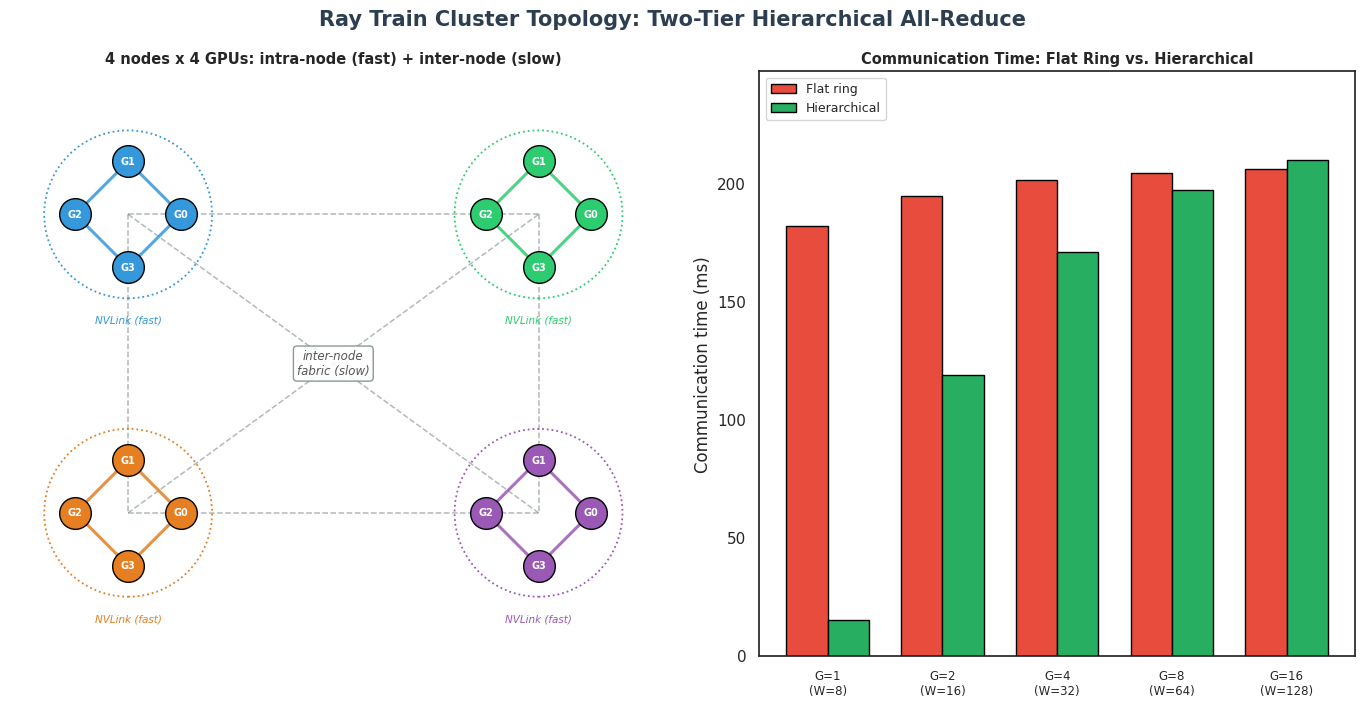

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(14, 7.2), gridspec_kw={"width_ratios": [1.15, 1]})
fig.suptitle("Ray Train Cluster Topology: Two-Tier Hierarchical All-Reduce", fontsize=15, fontweight='bold', color="#2c3e50")

# --- Left: two-tier topology diagram ---
ax = axes[0]
ax.set_title("4 nodes x 4 GPUs: intra-node (fast) + inter-node (slow)", fontsize=10.5, fontweight='bold')
n_nodes, gpus_per_node = 4, 4
node_centers = [(-3.3, 2.4), (3.3, 2.4), (-3.3, -2.4), (3.3, -2.4)]
node_colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

for (cx, cy), clr in zip(node_centers, node_colors):
    angles = np.linspace(0, 2 * np.pi, gpus_per_node, endpoint=False)
    gx = cx + 0.85 * np.cos(angles)
    gy = cy + 0.85 * np.sin(angles)
    for i in range(gpus_per_node):
        j = (i + 1) % gpus_per_node
        ax.plot([gx[i], gx[j]], [gy[i], gy[j]], color=clr, lw=2.2, zorder=2, alpha=0.85)
    ax.scatter(gx, gy, s=520, color=clr, edgecolor="black", zorder=3)
    for i in range(gpus_per_node):
        ax.text(gx[i], gy[i], f"G{i}", ha="center", va="center", fontsize=7, fontweight="bold", color="white", zorder=4)
    ax.add_patch(plt.Circle((cx, cy), 1.35, fill=False, edgecolor=clr, lw=1.3, linestyle=":", zorder=1))
    ax.text(cx, cy - 1.75, "NVLink (fast)", ha="center", fontsize=7.5, color=clr, style="italic")

for i in range(n_nodes):
    for j in range(i + 1, n_nodes):
        (x1, y1), (x2, y2) = node_centers[i], node_centers[j]
        ax.plot([x1, x2], [y1, y2], color="#7f8c8d", lw=1.1, linestyle="--", zorder=0, alpha=0.6)

ax.text(0, 0, "inter-node\nfabric (slow)", ha="center", va="center", fontsize=8.5, color="#555555",
        style="italic", bbox=dict(boxstyle="round", fc="white", ec="#7f8c8d", alpha=0.9))

ax.set_xlim(-5.2, 5.2)
ax.set_ylim(-4.7, 4.7)
ax.set_aspect("equal")
ax.axis("off")

# --- Right: T_flat vs T_hier bar comparison across cluster shapes ---
ax2 = axes[1]
ax2.set_title("Communication Time: Flat Ring vs. Hierarchical", fontsize=10.5, fontweight='bold')
labels = [f"G={g_}\n(W={w_})" for g_, _, w_, _, _ in results]
x = np.arange(len(results))
width = 0.36
flat_ms = [r[3] * 1000 for r in results]
hier_ms = [r[4] * 1000 for r in results]

ax2.bar(x - width / 2, flat_ms, width, color="#e74c3c", edgecolor="black", label="Flat ring")
ax2.bar(x + width / 2, hier_ms, width, color="#27ae60", edgecolor="black", label="Hierarchical")

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_ylabel("Communication time (ms)")
ax2.set_ylim(0, max(flat_ms) * 1.2)
ax2.legend(loc="upper left", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


*(Insight: The left diagram makes the physical asymmetry visible -- solid colored rings are fast NVLink loops fully contained inside one node, while the dashed grey lines connecting nodes represent the much slower fabric hierarchical all-reduce deliberately minimizes crossing. The right panel shows the honest numerical picture: hierarchical (green) starts far cheaper than flat (red) at small node counts, but the gap visibly closes moving right, and by G=16 the bars cross -- green edges above red. Both curves share the same ring-saturation shape from Lesson 05, so this is not noise; it is the fixed intra-node tax hierarchical always pays catching up with a shrinking inter-node saving.)*

## Real-World Use Case or Analogy

Think of hierarchical all-reduce as **A Multinational Company's Quarterly Numbers Rollup**:

* **A Worker (One Employee's Local Numbers):** Every employee has their own local sales figures for the quarter -- accurate, but only for their own desk.
* **Intra-Node All-Reduce (Each Office Compiling Its Own Total First):** Before anything leaves the building, everyone in the same office walks down the hall and combines numbers with their office-mates -- fast, because they're all under one roof and can just talk directly.
* **Inter-Node All-Reduce (Only the Office Totals Go to Headquarters):** Only ONE combined number per office -- not every individual employee's number -- travels over the slow, expensive international phone line to headquarters and back. Headquarters combines those few office totals and sends the true company-wide total back to each office.
* **Intra-Node Broadcast (The Office Sharing the Final Company Number):** Once an office has the true company-wide total, sharing it with everyone at that office again is fast and local.
* **The Flat-Ring Alternative (Every Single Employee Calling Headquarters Directly):** Imagine instead if every employee, everywhere, individually dialed the same expensive international line to reconcile their number one-on-one with every other employee worldwide -- technically it converges to the same final total, but at wildly higher long-distance cost.
* **The Straggler Effect (Waiting on the One Slow Office):** Headquarters can't finalize the quarterly number until every office reports in -- and one perpetually slow office, even with perfectly capable staff, sets the pace for the entire company's close date, and that risk only grows as more offices are added.

The generalizable lesson is that any synchronization problem with a natural "local group, then global" structure should exploit that structure -- collapsing local information first and only exchanging the minimal summarized result over the expensive long-haul link, rather than treating every participant as equally far from every other.